# Category Recall by LPP

> Compute and visualize category-filtered recall rate as a function of LPP amplitude.

This analysis bins items by their LPP amplitude and computes recall rate within each bin, filtered by category. It tests whether higher neural encoding signals predict better subsequent memory for different item types.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |
| `category_field` | Key providing item categories per study position |
| `lpp_field` | Key providing LPP values |
| `contrast_name` | Legend title |
| `category_values` | Category values to plot |
| `labels` | Legend labels per category |
| `color_cycle` | Colors for each curve |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.cat_recall_by_lpp import cat_recall_by_lpp, plot_cat_recall_by_lpp, category_recall_counts, category_lpp_recall_histogram
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "Category Recall by LPP"
data_path = "data/TalmiEEG.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['subject'] > 0"
category_field = "condition"
category_values = [1, 2]
lpp_field = "EarlyLPP"
labels = ["Negative", "Neutral"]
color_cycle = ["red", "black"]
contrast_name = "condition"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

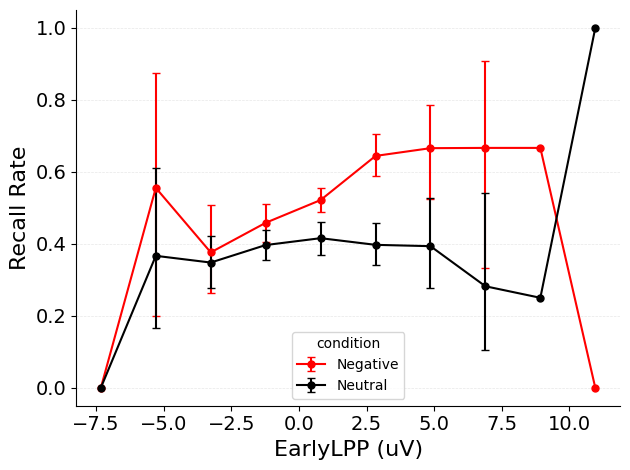

In [5]:
#| code-summary: Plot category-filtered recall rate by LPP amplitude
#| label: fig-cat-recall-by-lpp
#| fig-cap: "Category-filtered recall rate by LPP amplitude."
plot_cat_recall_by_lpp(data, trial_mask, category_field=category_field, category_values=category_values, lpp_field=lpp_field, labels=labels, color_cycle=color_cycle, contrast_name=contrast_name)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_cat_recall_by_lpp)

---

### plot_cat_recall_by_lpp

>      plot_cat_recall_by_lpp (datasets:Union[Sequence[jaxcmr.typing.RecallDatas
>                              et],jaxcmr.typing.RecallDataset], trial_masks:Uni
>                              on[Sequence[jaxtyping.Bool[Array,'trial_count']],
>                              jaxtyping.Bool[Array,'trial_count']],
>                              category_field:str,
>                              category_values:Sequence[int],
>                              lpp_field:str='LateLPP', bin_edges:Optional[jaxty
>                              ping.Float[Array,'bin_count_plus_one']]=None,
>                              bin_count:int=10,
>                              color_cycle:Optional[list[str]]=None,
>                              labels:Optional[Sequence[str]]=None,
>                              contrast_name:Optional[str]=None,
>                              axis:Optional[matplotlib.axes._axes.Axes]=None,
>                              confidence_level:float=0.95)

*Plot category-filtered recall rate by LPP bins.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| category_field | str |  | Key providing item categories per study position. |
| category_values | Sequence |  | Categories to plot. |
| lpp_field | str | LateLPP | Key providing LPP values per study position. |
| bin_edges | Optional | None | LPP bin edges; computed from data if ``None``. |
| bin_count | int | 10 | Number of bins when ``bin_edges`` is not provided. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the LPP-binned recall plot.** |

In [7]:
#| echo: false
show_doc(cat_recall_by_lpp)

---

### cat_recall_by_lpp

>      cat_recall_by_lpp (dataset:jaxcmr.typing.RecallDataset,
>                         category_field:str, category_value:int,
>                         lpp_field:str='LateLPP', bin_edges:Optional[jaxtyping.
>                         Float[Array,'bin_count_plus_one']]=None,
>                         bin_count:int=10)

*Category-filtered recall rate by LPP bins.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with per-item LPP metadata. |
| category_field | str |  | Key providing item categories per study position. |
| category_value | int |  | Category to filter on. |
| lpp_field | str | LateLPP | Key providing LPP values per study position. |
| bin_edges | Optional | None | LPP bin edges; computed from data if ``None``. |
| bin_count | int | 10 | Number of bins when ``bin_edges`` is not provided. |
| **Returns** | **Float[Array, 'bin_count']** |  | **Recall rate per LPP bin.** |

In [8]:
#| echo: false
show_doc(category_lpp_recall_histogram)

---

### category_lpp_recall_histogram

>      category_lpp_recall_histogram
>                                     (recalls:jaxtyping.Integer[Array,'trial_co
>                                     untrecall_positions'], lpp:jaxtyping.Float
>                                     [Array,'trial_countstudy_positions'], cate
>                                     gories:jaxtyping.Integer[Array,'trial_coun
>                                     tstudy_positions'], category_value:int, bi
>                                     n_edges:jaxtyping.Float[Array,'bin_count_p
>                                     lus_one'], list_length:int)

*Category-filtered recall rate binned by LPP.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| recalls | Integer[Array, 'trial_count recall_positions'] | Recalled items (1-indexed; 0 for no recall). |
| lpp | Float[Array, 'trial_count study_positions'] | LPP values per study position. |
| categories | Integer[Array, 'trial_count study_positions'] | Item categories per study position. |
| category_value | int | Category to filter on. |
| bin_edges | Float[Array, 'bin_count_plus_one'] | LPP bin edges. |
| list_length | int | Study-list length. |
| **Returns** | **Float[Array, 'bin_count']** | **Recall rate per LPP bin.** |